# 🔍 Notebook 4 — Outlier Detection & Handling

**Goal:** Find and handle abnormal data points that could confuse the ML model.
Outliers in petrol pump data could be: festival spikes, equipment failures, data entry errors.

**Methods used:**
1. IQR (Interquartile Range) method — simple statistical method
2. Z-Score method — standard deviation based
3. Isolation Forest — ML-based outlier detection
4. Visual inspection with box plots
5. Decision: cap outliers (winsorizing) vs remove vs keep

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/clean_data.csv', parse_dates=['Date'])
print(f'Loaded {len(df)} rows ✅')

# Columns to check for outliers
NUMERIC_COLS = ['Total_Sold', 'Opening_Stock', 'MS_Sold',
                'HSD1_Sold', 'HSD2_Sold', 'HSD3_Sold',
                'Cash', 'Online', 'Card']

Loaded 806 rows ✅


## Step 1 — Box Plots to Visually Spot Outliers

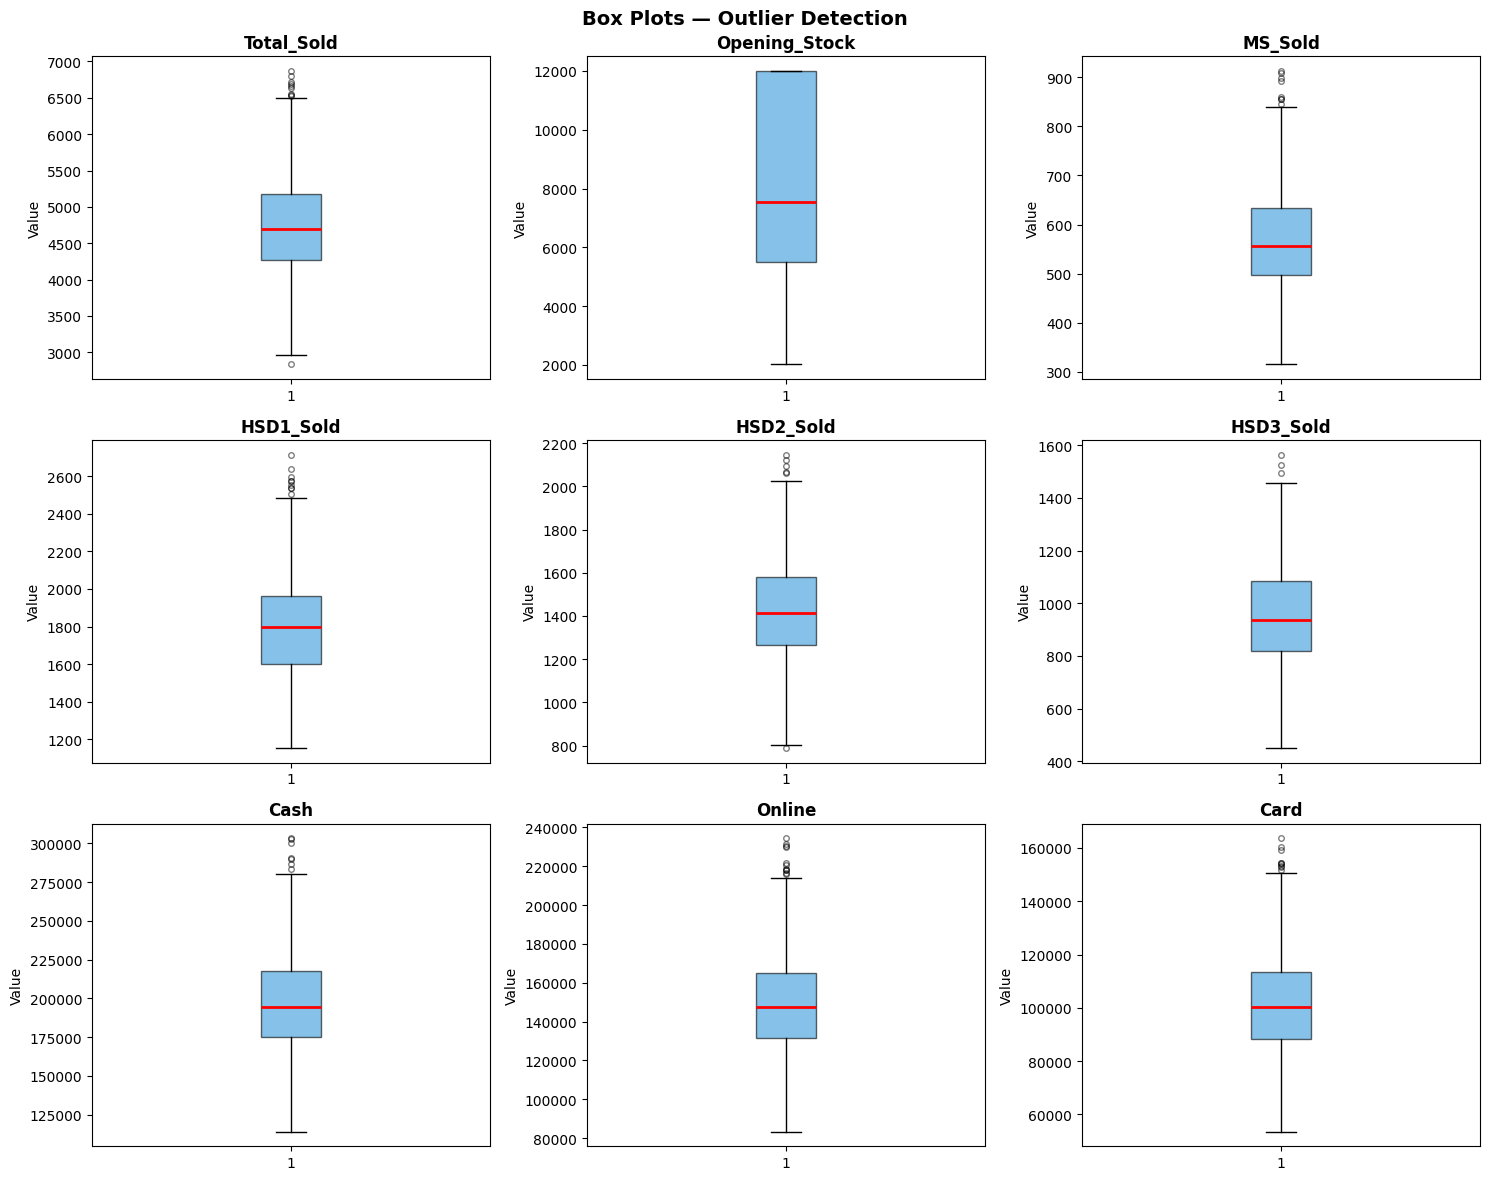

Red dots above/below the whiskers = outliers


In [2]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(NUMERIC_COLS):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#3498db', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', color='red',
                                   markersize=4, alpha=0.5))
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Value')

plt.suptitle('Box Plots — Outlier Detection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/viz_outlier_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Red dots above/below the whiskers = outliers')

## Step 2 — IQR Method

In [3]:
# IQR method: outlier if value < Q1 - 1.5*IQR  or  > Q3 + 1.5*IQR
print('=== IQR Outlier Detection ===')
iqr_results = {}

for col in NUMERIC_COLS:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    iqr_results[col] = {
        'Lower_Bound': round(lower, 1),
        'Upper_Bound': round(upper, 1),
        'Outlier_Count': len(outliers),
        'Outlier_Pct': round(len(outliers) / len(df) * 100, 2)
    }
    print(f'{col:<20} | bounds: [{lower:.0f}, {upper:.0f}] | outliers: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)')

iqr_df = pd.DataFrame(iqr_results).T
print(f'\nTotal outlier rows (IQR): varies by column')

=== IQR Outlier Detection ===
Total_Sold           | bounds: [2931, 6516] | outliers: 10 (1.2%)
Opening_Stock        | bounds: [-4210, 21726] | outliers: 0 (0.0%)
MS_Sold              | bounds: [292, 840] | outliers: 8 (1.0%)
HSD1_Sold            | bounds: [1060, 2503] | outliers: 9 (1.1%)
HSD2_Sold            | bounds: [800, 2047] | outliers: 6 (0.7%)
HSD3_Sold            | bounds: [416, 1487] | outliers: 3 (0.4%)
Cash                 | bounds: [110730, 282175] | outliers: 7 (0.9%)
Online               | bounds: [81923, 214809] | outliers: 11 (1.4%)
Card                 | bounds: [50835, 151213] | outliers: 9 (1.1%)

Total outlier rows (IQR): varies by column


## Step 3 — Z-Score Method

In [4]:
# Z-Score: outlier if |z| > 3  (more than 3 standard deviations from mean)
print('=== Z-Score Outlier Detection (|z| > 3) ===')

zscore_outliers = pd.Series(False, index=df.index)

for col in NUMERIC_COLS:
    z = np.abs(stats.zscore(df[col].fillna(df[col].mean())))
    col_outliers = z > 3
    count = col_outliers.sum()
    zscore_outliers = zscore_outliers | col_outliers
    print(f'{col:<20} : {count} outliers ({count/len(df)*100:.2f}%)')

print(f'\nRows flagged by Z-Score in ANY column: {zscore_outliers.sum()} ({zscore_outliers.sum()/len(df)*100:.1f}%)')

=== Z-Score Outlier Detection (|z| > 3) ===
Total_Sold           : 1 outliers (0.12%)
Opening_Stock        : 0 outliers (0.00%)
MS_Sold              : 4 outliers (0.50%)
HSD1_Sold            : 2 outliers (0.25%)
HSD2_Sold            : 2 outliers (0.25%)
HSD3_Sold            : 2 outliers (0.25%)
Cash                 : 3 outliers (0.37%)
Online               : 4 outliers (0.50%)
Card                 : 3 outliers (0.37%)

Rows flagged by Z-Score in ANY column: 13 (1.6%)


## Step 4 — Isolation Forest (ML-based)

In [5]:
# Isolation Forest: learns what 'normal' looks like, flags anomalies
# contamination = expected % of outliers in dataset
X_iso = df[NUMERIC_COLS].fillna(0)

iso = IsolationForest(contamination=0.03, random_state=42, n_jobs=-1)
iso_preds = iso.fit_predict(X_iso)

# -1 = outlier, 1 = normal
df['Is_Outlier_IsoForest'] = (iso_preds == -1).astype(int)

n_outliers = df['Is_Outlier_IsoForest'].sum()
print(f'Isolation Forest found: {n_outliers} outliers ({n_outliers/len(df)*100:.1f}%)')

# Show what outliers look like
print('\nSample outlier rows:')
df[df['Is_Outlier_IsoForest'] == 1][NUMERIC_COLS + ['Refill_Required']].head(10)

Isolation Forest found: 25 outliers (3.1%)

Sample outlier rows:


,Total_Sold,Opening_Stock,MS_Sold,HSD1_Sold,HSD2_Sold,HSD3_Sold,Cash,Online,Card,Refill_Required
103,6408.0,2111.0,893.0,2538.0,1890.0,1087.0,274872,175322.0,125665,Yes
111,6362.0,6075.0,724.0,2485.0,1933.0,1220.0,272855,220419.0,163590,Yes
171,3117.0,8329.0,411.0,1270.0,932.0,504.0,121999,103883.0,58109,No
196,2965.0,7195.0,337.0,1197.0,804.0,627.0,138165,102915.0,53570,No
198,3314.0,12000.0,346.0,1189.0,939.0,840.0,140992,106306.0,66802,No
203,3254.0,2095.0,410.0,1299.0,952.0,593.0,154446,96200.0,68926,Yes
226,3249.0,8305.0,442.0,1276.0,995.0,536.0,138948,119932.0,60113,No
240,2999.0,12000.0,419.0,1208.0,921.0,451.0,128953,86348.0,54542,No
279,6399.0,6497.0,769.0,2324.0,1742.0,1564.0,228875,208513.0,160331,Yes
292,6632.0,6224.0,710.0,2639.0,2010.0,1273.0,250506,210384.0,128140,Yes


## Step 5 — Visualize Outliers on Time Series

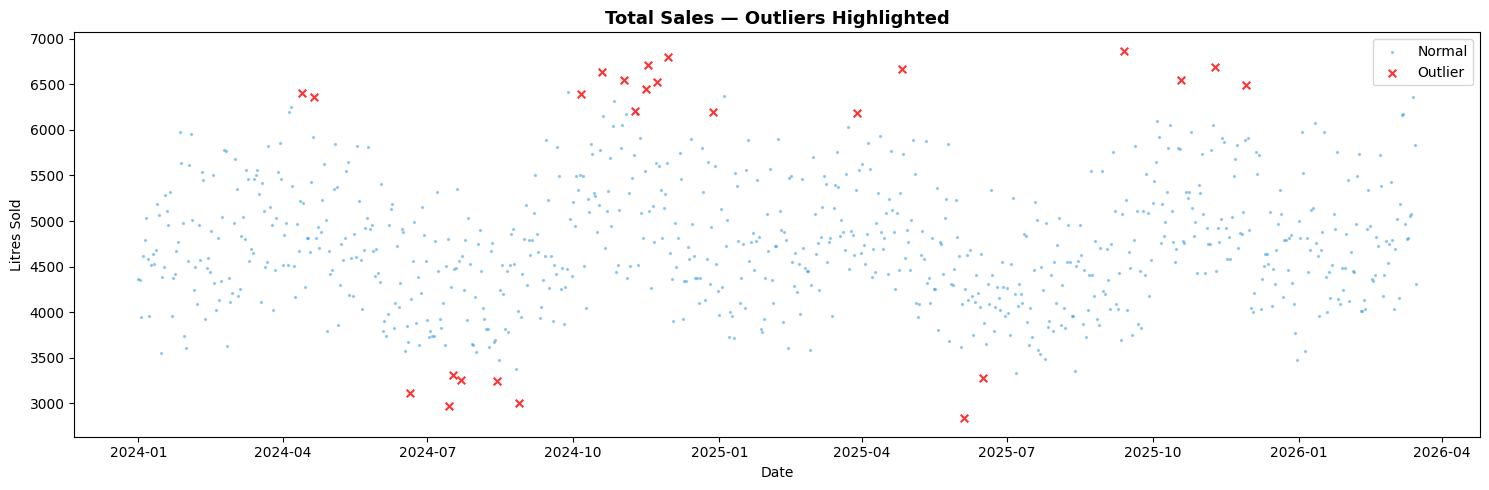

In [6]:
fig, ax = plt.subplots(figsize=(15, 5))

normal  = df[df['Is_Outlier_IsoForest'] == 0]
outlier = df[df['Is_Outlier_IsoForest'] == 1]

ax.scatter(normal['Date'], normal['Total_Sold'],
           s=2, alpha=0.4, color='#3498db', label='Normal')
ax.scatter(outlier['Date'], outlier['Total_Sold'],
           s=30, alpha=0.8, color='red', marker='x', label='Outlier', zorder=5)

ax.set_title('Total Sales — Outliers Highlighted', fontweight='bold', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Litres Sold')
ax.legend()
plt.tight_layout()
plt.savefig('../data/viz_outliers_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 6 — Handle Outliers (Winsorizing / Capping)

In [7]:
# DECISION: We cap outliers using 1st and 99th percentile
# Why cap instead of remove?
#   → Removing rows loses data (we have enough)
#   → Capping preserves the row but limits extreme values
#   → Festival spikes are REAL events — we don't want to lose them

df_clean = df.copy()

CAP_COLS = ['Total_Sold', 'MS_Sold', 'HSD1_Sold', 'HSD2_Sold', 'HSD3_Sold']

for col in CAP_COLS:
    p01 = df_clean[col].quantile(0.01)
    p99 = df_clean[col].quantile(0.99)
    before_min = df_clean[col].min()
    before_max = df_clean[col].max()
    df_clean[col] = df_clean[col].clip(lower=p01, upper=p99)
    after_min = df_clean[col].min()
    after_max = df_clean[col].max()
    print(f'{col:<15} before: [{before_min:.0f}, {before_max:.0f}]  after: [{after_min:.0f}, {after_max:.0f}]')

# Drop the isolation forest flag column (not a real feature)
df_clean.drop(columns=['Is_Outlier_IsoForest'], inplace=True)

print(f'\nRows before: {len(df)}')
print(f'Rows after : {len(df_clean)}  (no rows dropped, only values capped)')

# Save
df_clean.to_csv('../data/clean_data_no_outliers.csv', index=False)
print('\n✅ Saved: data/clean_data_no_outliers.csv')

Total_Sold      before: [2835, 6869]  after: [3333, 6526]
MS_Sold         before: [315, 913]  after: [375, 839]
HSD1_Sold       before: [1155, 2714]  after: [1270, 2503]
HSD2_Sold       before: [789, 2147]  after: [953, 1997]
HSD3_Sold       before: [451, 1564]  after: [593, 1437]

Rows before: 806
Rows after : 806  (no rows dropped, only values capped)

✅ Saved: data/clean_data_no_outliers.csv
